## A National Shock with Local Outcomes
### FHA Purchase Lending, September 2019 → September 2023

**Audience:** federal housing policymakers (HUD/FHA leadership, House and Senate housing staff)

**Question:** the payment on the median FHA purchase loan rose 89% between 2019 and 2023.
Did the markets that lost the most FHA buyers suffer the largest payment increases?

**Answer: no.** That null result is the finding, and this notebook shows how I got there.

*Lasya Raghavendra : AEI Housing Center Data Analysis & Coding Assessment*

In [2]:
# !pip install pandas numpy matplotlib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

RAW = "data/fha_snap_sep.csv"   # source folder
FIGS = "figures"                # output folder

import os; os.makedirs(FIGS, exist_ok=True)

### 1. What is this data?

Before asking anything of the data I want to know what a row is, what varies, and what is unusable.

In [6]:
df = pd.read_csv(RAW, low_memory=False)

print("shape:", df.shape)
display(df.head(3))

# how much of each column is actually populated
print("\n--- null % (top 10) ---")
print((df.isna().mean() * 100).round(1).sort_values(ascending=False).head(10))

shape: (171098, 44)


,LoanID,state,PropertyCity,PropertyCounty,PropertyZip,OriginationMortgageeSponsorOr,OriginatingMortgageeNumber,SponsorName,SponsorNumber,DownPaymentSource,NonProfitNumber,ProductType,LoanPurpose,PropertyType,InterestRate,OriginalMortgageAmount,EndorsementYear,EndorsementMonth,R,S,T,U,V,W,FIPSCODE,Purpose,lender,lender_name,OrigMonth_est,year,OrigDt_est,Orig,X,Y,Z,AA,OrigNum,SponsorNum,PropertyTypeFinal,OriginatingMortgagee,cbsa,cbsaname,month,quarter
0,8604621,AK,ANCHORAGE,ANCHORAGE,99501,"UNITED SHORE FINANCIAL SERVICES, LLC",Not Available,"UNITED SHORE FINANCIAL SERVICES, LLC",71845,Borrower,Not Avail,Fixed Rate,Purchase,Single Family,3.001,252345,2019,10,NaN,NaN,NaN,NaN,NaN,NaN,2020.0,Purchase,"United Shore Financial Services, Llc","UNITED SHORE FINANCIAL SERVICES, LLC",9,2019,716,716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11260.0,"Anchorage, AK",9,3
1,8604622,AK,ANCHORAGE,ANCHORAGE,99501,RESIDENTIAL MORTGAGE LLC,12511,Not Available,Not Available,Borrower,Not Avail,Fixed Rate,Purchase,Condo,3.875,104080,2019,10,NaN,NaN,NaN,NaN,NaN,NaN,2020.0,Purchase,Residential Mortgage Llc,Residential Mortgage Services,9,2019,716,716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11260.0,"Anchorage, AK",9,3
2,8604624,AK,ANCHORAGE,ANCHORAGE,99502,PRIMELENDING A PLAINSCAPITAL COMPANY,73663,Not Available,Not Available,Borrower,Not Avail,Fixed Rate,Purchase,Single Family,3.250,313123,2019,10,NaN,NaN,NaN,NaN,NaN,NaN,2020.0,Purchase,Primelending A Plainscapital Company,Primelending,9,2019,716,716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11260.0,"Anchorage, AK",9,3



--- null % (top 10) ---
V          100.0
AA         100.0
U          100.0
T          100.0
S          100.0
R          100.0
Y          100.0
Z          100.0
X          100.0
OrigNum    100.0
dtype: float64


In [7]:
# one month per year, or a full panel?
print(pd.crosstab(df["year"], df["month"]))
print()

# which columns carry real variation
for c in ["LoanPurpose", "Purpose", "ProductType", "PropertyType", "DownPaymentSource"]:
    print(f"--- {c} ({df[c].nunique()} levels) ---")
    print(df[c].value_counts(dropna=False))
    print()

print("duplicate LoanIDs:", df["LoanID"].duplicated().sum())
print("states =", df["state"].nunique(),
      "| counties =", df["PropertyCounty"].nunique(),
      "| CBSAs =", df["cbsaname"].nunique(),
      "| CBSA null % =", round(df["cbsaname"].isna().mean()*100, 1))

month      9
year        
2019   70291
2022   49193
2023   51614

--- LoanPurpose (1 levels) ---
LoanPurpose
Purchase    171098
Name: count, dtype: int64

--- Purpose (1 levels) ---
Purpose
Purchase    171098
Name: count, dtype: int64

--- ProductType (2 levels) ---
ProductType
Fixed Rate         170988
Adjustable Rate       110
Name: count, dtype: int64

--- PropertyType (3 levels) ---
PropertyType
Single Family     166376
Condo               3590
Rehabilitation      1132
Name: count, dtype: int64

--- DownPaymentSource (5 levels) ---
DownPaymentSource
Borrower      121664
Relative       46031
Gov Asst        1793
Employer        1242
Non Profit       368
Name: count, dtype: int64

duplicate LoanIDs: 0
states = 51 | counties = 1758 | CBSAs = 379 | CBSA null % = 13.6


**Takeaways that shape everything downstream:**

- Three September snapshots: 2019 (70,291), 2022 (49,193), 2023 (51,614). Not a panel; no loan appears twice.
- `LoanPurpose` and `Purpose` are 100% "Purchase", and 99.9% of loans are fixed-rate. Neither can segment anything, drop them as analytic variables.
- 14 of 44 columns are entirely empty (`R`–`W`, `X`–`AA`, and four `*Num` fields). Artifacts of the export.
- No borrower income, credit score, or LTV. **This is the binding constraint on the whole analysis**, I cannot control for who is borrowing, only observe what they borrowed.
- Geography is rich: 51 states, 1,758 counties, 379 CBSAs. 13.6% of loans are non-metro.

So the usable variation is: **price, rate, geography, time.** The analysis has to live there.

In [8]:
# drop the empty columns
dead = [c for c in df.columns if df[c].isna().all()]
print("dropping all-null columns:", dead)

keep = ["LoanID","state","PropertyCity","PropertyCounty","PropertyZip","FIPSCODE",
        "cbsa","cbsaname","OriginationMortgageeSponsorOr","SponsorName","lender_name",
        "DownPaymentSource","ProductType","PropertyType","InterestRate",
        "OriginalMortgageAmount","year"]

d = df[keep].copy()
d = d.rename(columns={"OriginalMortgageAmount": "loan_amt",
                      "InterestRate": "rate",
                      "OriginationMortgageeSponsorOr": "originator"})

# guard against bad values before trusting any aggregate
print("\nrate range:", d.rate.min(), "-", d.rate.max())
print("loan range:", d.loan_amt.min(), "-", d.loan_amt.max())
print("implausible rates (<1 or >12):", ((d.rate < 1) | (d.rate > 12)).sum())
print("rows retained:", len(d))

dropping all-null columns: ['R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'AA', 'OrigNum', 'SponsorNum', 'PropertyTypeFinal', 'OriginatingMortgagee']

rate range: 2.5 - 8.9
loan range: 12966 - 1374642
implausible rates (<1 or >12): 0
rows retained: 171098


### 2. The right unit of analysis is the payment, not the price

House prices are the usual affordability metric, but no household buys a price, it buys a monthly
payment. With rates moving from 3.9% to 6.8%, price and payment diverge sharply, and the payment is
what actually binds at underwriting.

I compute level 30-year principal and interest from the note rate and original mortgage amount.

**MIP is excluded deliberately.** FHA mortgage insurance applies at roughly uniform rates across all
three cohorts, so including it would raise every payment by a similar proportion without changing any
comparison in this memo. Excluding it keeps the calculation transparent and reproducible.

In [9]:
def monthly_pi(principal, annual_rate_pct, years=30):
    """Level-payment principal & interest on a 30-year fixed."""
    i = annual_rate_pct / 100 / 12
    n = years * 12
    return principal * i / (1 - (1 + i) ** -n)

d["pi"] = monthly_pi(d.loan_amt, d.rate)

summary = d.groupby("year").agg(
    loans    = ("LoanID", "count"),
    med_loan = ("loan_amt", "median"),
    med_rate = ("rate", "median"),
    med_pi   = ("pi", "median"),
).round(2)

# index both to 2019 to see which one moved
summary["loan_idx"] = (summary.med_loan / summary.med_loan.iloc[0] * 100).round(0)
summary["pi_idx"]   = (summary.med_pi   / summary.med_pi.iloc[0]   * 100).round(0)
display(summary)

,loans,med_loan,med_rate,med_pi,loan_idx,pi_idx
year,,,,,,
2019,70291,208160.0,3.88,988.50,100.0,100.0
2022,49193,272964.0,5.62,1544.24,131.0,156.0
2023,51614,293584.0,6.75,1872.20,141.0,189.0


**Loan size +41%. Payment +89%.**

Rates, not prices, did most of the damage. That matters for policy: a price correction would not
restore the 2019 payment, and it happened far faster than incomes could adjust.

National purchase volume fell 27%. The obvious next question is where and whether the places
that lost the most buyers are the places where payments rose the most.

### 3. Hypothesis: the metros with the biggest payment increases lost the most buyers

This is the intuitive story and the one I expected to confirm. I test it directly before building
anything on top of it.

In [10]:
g = (d[d.cbsaname.notna()]
     .groupby(["cbsaname", "year"])
     .agg(loans=("LoanID", "count"), med_pi=("pi", "median"))
     .unstack("year"))

vol, pi = g["loans"], g["med_pi"]

metro = pd.DataFrame({
    "loans_2019":  vol[2019],
    "loans_2023":  vol[2023],
    "vol_chg_pct": (vol[2023] / vol[2019] - 1) * 100,
    "pi_2019":     pi[2019],
    "pi_2023":     pi[2023],
    "pi_chg_pct":  (pi[2023] / pi[2019] - 1) * 100,
}).dropna()

# small metros produce unstable percentages, so require a real 2019 base
metro = metro[metro.loans_2019 >= 200].round(1)
print("metros retained:", len(metro))

print("\n--- 10 biggest declines ---")
display(metro.sort_values("vol_chg_pct").head(10))
print("--- 10 most resilient ---")
display(metro.sort_values("vol_chg_pct", ascending=False).head(10))

metros retained: 84

--- 10 biggest declines ---


,loans_2019,loans_2023,vol_chg_pct,pi_2019,pi_2023,pi_chg_pct
cbsaname,,,,,,
"Worcester, MA",219,93,-57.5,1191.2,2612.3,119.3
"Bethesda-Frederick-Gaithersburg, MD",244,105,-57.0,1501.8,2712.7,80.6
"Hartford-West Hartford-East Hartford, C",406,175,-56.9,903.4,1863.9,106.3
"Grand Rapids-Wyoming, MI",209,90,-56.9,763.1,1615.2,111.7
"San Diego-Carlsbad-San Marcos, CA",310,134,-56.8,2102.8,4457.0,112.0
"Boston-Quincy, MA",245,106,-56.7,1784.9,3508.6,96.6
"Warren-Farmington-Hills-Troy, MI",557,247,-55.7,846.3,1533.9,81.2
"Allentown-Bethlehem-Easton, PA-NJ",265,126,-52.5,833.0,1699.0,104.0
"Wilmington, DE-MD-NJ",276,132,-52.2,1031.3,2062.6,100.0


--- 10 most resilient ---


,loans_2019,loans_2023,vol_chg_pct,pi_2019,pi_2023,pi_chg_pct
cbsaname,,,,,,
"Lakeland, FL",415,560,34.9,956.4,1906.1,99.3
"San Antonio, TX",792,840,6.1,948.0,1638.6,72.9
"Cape Coral-Fort Myers, FL",327,333,1.8,993.2,2200.0,121.5
"Houston-Baytown-Sugar Land, TX",1886,1892,0.3,1019.7,1754.4,72.1
"Charleston-North Charleston, SC",225,222,-1.3,1053.0,2005.8,90.5
"Tulsa, OK",259,254,-1.9,740.2,1538.0,107.8
"Austin-Round Rock, TX",498,480,-3.6,1173.0,2098.1,78.9
"Dallas-Plano-Irving, TX",1282,1215,-5.2,1156.8,2034.9,75.9
"Jacksonville, FL",421,393,-6.7,991.3,1871.9,88.8


In [11]:
# does payment movement predict volume outcomes?
for c in ["pi_2019", "pi_2023", "pi_chg_pct"]:
    r   = metro.vol_chg_pct.corr(metro[c])
    rho = metro.vol_chg_pct.rank().corr(metro[c].rank())
    print(f"vol_chg vs {c:>10}:  pearson={r:6.3f}   rank={rho:6.3f}")

print(f"\npayment growth spread: p10={metro.pi_chg_pct.quantile(.10):.0f}%  p90={metro.pi_chg_pct.quantile(.90):.0f}%")
print(f"volume change spread:  p10={metro.vol_chg_pct.quantile(.10):.0f}%  p90={metro.vol_chg_pct.quantile(.90):.0f}%")

vol_chg vs    pi_2019:  pearson=-0.233   rank=-0.178
vol_chg vs    pi_2023:  pearson=-0.267   rank=-0.215
vol_chg vs pi_chg_pct:  pearson=-0.126   rank=-0.116

payment growth spread: p10=77%  p90=117%
volume change spread:  p10=-52%  p90=-8%


**Hypothesis rejected.** The correlation between payment growth and volume change is −0.13.

Note what this is not: payment growth does vary meaningfully across metros (p10 = 77%, p90 = 117%).
The problem is not that the predictor is constant, it is that its variation is unrelated to the
outcome. Payment level does slightly better (−0.27) but still explains little.

Rather than discard this, I quantify it. If payment shock is not the differentiator, what is?

In [13]:
NE = ["CT","ME","MA","NH","RI","VT","NJ","NY","PA"]
MW = ["IL","IN","MI","OH","WI","IA","KS","MN","MO","NE","ND","SD"]
SO = ["DE","DC","FL","GA","MD","NC","SC","VA","WV","AL","KY","MS","TN","AR","LA","OK","TX"]
WE = ["AZ","CO","ID","MT","NV","NM","UT","WY","AK","CA","HI","OR","WA"]
REGION = {**{s:"Northeast" for s in NE}, **{s:"Midwest" for s in MW},
          **{s:"South" for s in SO}, **{s:"West" for s in WE}}

d["region"] = d.state.map(REGION)
assert d.region.notna().all(), "unmapped states"
metro["region"] = d.groupby("cbsaname").region.agg(lambda s: s.mode()[0])

y   = metro.vol_chg_pct
sst = ((y - y.mean())**2).sum()

# variation explained by region alone
ssb  = sum(len(grp) * (grp.mean() - y.mean())**2 for _, grp in y.groupby(metro.region))
eta2 = ssb / sst

# variation explained by payment
r2_pichg = y.corr(metro.pi_chg_pct)**2
r2_pi23  = y.corr(metro.pi_2023)**2

# both together, via least squares on region dummies plus payment growth
X = pd.get_dummies(metro.region, drop_first=True).astype(float)
X["pi_chg_pct"] = metro.pi_chg_pct
X.insert(0, "const", 1.0)
beta, *_ = np.linalg.lstsq(X.values, y.values, rcond=None)
r2_both  = 1 - ((y - X.values @ beta)**2).sum() / sst

print("Share of cross-metro variation in volume change explained by:")
print(f"  payment growth 2019-2023 : {r2_pichg:.3f}")
print(f"  payment level  2023      : {r2_pi23:.3f}")
print(f"  region                   : {eta2:.3f}")
print(f"  region + payment growth  : {r2_both:.3f}   -- payment adds {r2_both-eta2:+.3f}")

Share of cross-metro variation in volume change explained by:
  payment growth 2019-2023 : 0.016
  payment level  2023      : 0.071
  region                   : 0.430
  region + payment growth  : 0.431   -- payment adds +0.002


**Region explains 43% of the variation. Payment growth explains 1.6%, and adds +0.002 once region is known.**

This reframes the entire question. The payment shock was the trigger, it hit every market. It was
not the differentiator, it does not explain who kept access.

One caution I want to state plainly: region is a **proxy**, not a mechanism. It stands in for a
bundle of local conditions: supply response, migration, land use, construction cost. This data
cannot separate them. What it can establish is that the differentiating factor is local, not federal.

In [14]:
vol_r = d.pivot_table(index="region", columns="year", values="LoanID", aggfunc="count")
pi_r  = d.pivot_table(index="region", columns="year", values="pi",     aggfunc="median")

reg = pd.DataFrame({
    "loans_2019":  vol_r[2019],
    "loans_2023":  vol_r[2023],
    "vol_chg_pct": (vol_r[2023]/vol_r[2019] - 1) * 100,
    "pi_2019":     pi_r[2019],
    "pi_2023":     pi_r[2023],
    "pi_chg_pct":  (pi_r[2023]/pi_r[2019] - 1) * 100,
}).round(1).sort_values("vol_chg_pct")

display(reg)
print(f"\nnational volume change: {(len(d[d.year==2023])/len(d[d.year==2019]) - 1)*100:.1f}%")
print(f"payment growth spans {reg.pi_chg_pct.max()-reg.pi_chg_pct.min():.0f}pp; "
      f"volume change spans {reg.vol_chg_pct.max()-reg.vol_chg_pct.min():.0f}pp")

,loans_2019,loans_2023,vol_chg_pct,pi_2019,pi_2023,pi_chg_pct
region,,,,,,
Northeast,9796,5328,-45.6,1026.6,2025.3,97.3
Midwest,14180,9339,-34.1,756.8,1402.4,85.3
West,15139,10055,-33.6,1321.0,2531.5,91.6
South,31176,26892,-13.7,948.0,1806.9,90.6



national volume change: -26.6%
payment growth spans 12pp; volume change spans 32pp


**The Midwest is the case that settles it.** Lowest median payment in the country in 2023 ($1,402),
and it still lost 34% of its FHA buyers. The South, with payments 29% higher, lost 14%.

If affordability alone drove outcomes, this ordering would be impossible.

In [15]:
bands  = [0, 1000, 1500, 2000, 2500, np.inf]
labels = ["<$1,000", "$1,000–1,500", "$1,500–2,000", "$2,000–2,500", "$2,500+"]
d["pi_band"] = pd.cut(d.pi, bins=bands, labels=labels)

tier = (pd.crosstab(d.pi_band, d.year, normalize="columns") * 100).round(1)
display(tier)

print("Share of FHA purchase loans with P&I under $1,000:")
for y_ in [2019, 2022, 2023]:
    print(f"  {y_}: {(d.loc[d.year==y_, 'pi'] < 1000).mean()*100:5.1f}%")

year,2019,2022,2023
pi_band,,,
"<$1,000",51.1,20.0,9.9
"$1,000–1,500",33.4,27.6,20.4
"$1,500–2,000",10.8,25.4,25.9
"$2,000–2,500",2.7,16.4,20.3
"$2,500+",1.9,10.6,23.5


Share of FHA purchase loans with P&I under $1,000:
  2019:  51.1%
  2022:  20.0%
  2023:   9.9%


**51% → 10%.** Half the 2019 FHA market bought at a payment point that has largely ceased to exist.
Loans above $2,500 went from 2% of originations to 23%.

FHA's statutory role is serving buyers with limited savings and moderate incomes. This is the clearest
available measure of that role contracting.

### 4. Figures

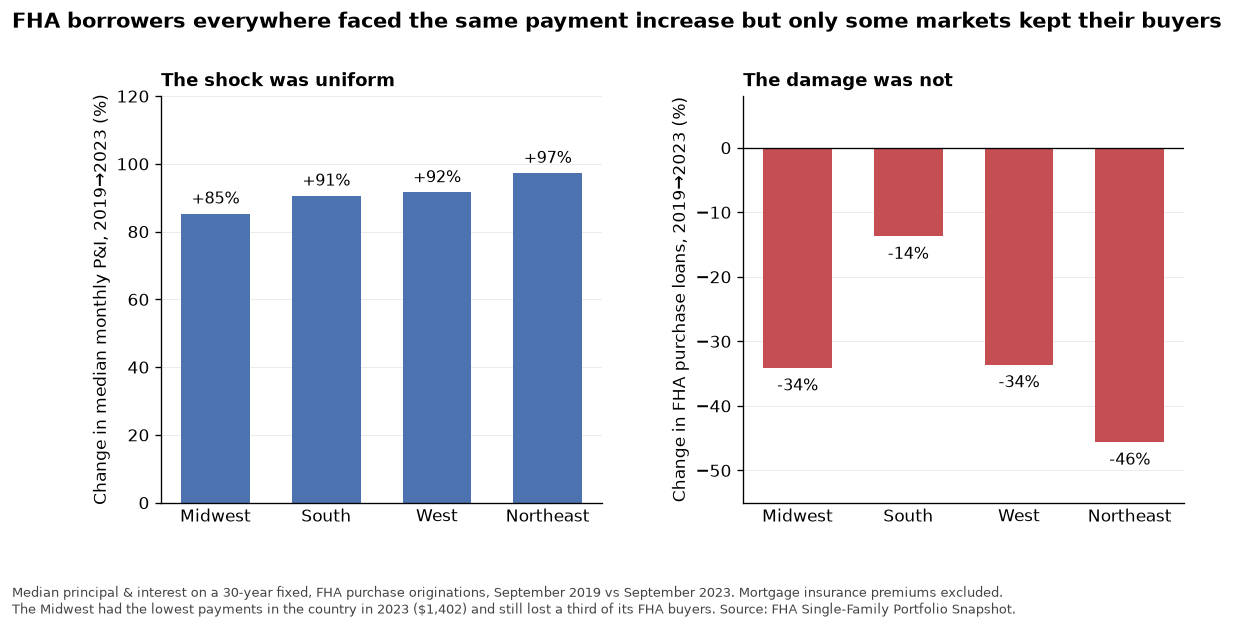

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), gridspec_kw={"wspace": 0.32})
order = ["Midwest", "South", "West", "Northeast"]
r = reg.loc[order]

ax = axes[0]
ax.bar(order, r.pi_chg_pct, color="#4c72b0", width=0.62)
ax.set_title("The shock was uniform", fontsize=11, fontweight="bold", loc="left")
ax.set_ylabel("Change in median monthly P&I, 2019→2023 (%)")
ax.set_ylim(0, 120)
for x, v in zip(order, r.pi_chg_pct):
    ax.text(x, v + 3, f"+{v:.0f}%", ha="center", fontsize=9.5)

ax = axes[1]
ax.bar(order, r.vol_chg_pct, color="#c44e52", width=0.62)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("The damage was not", fontsize=11, fontweight="bold", loc="left")
ax.set_ylabel("Change in FHA purchase loans, 2019→2023 (%)")
ax.set_ylim(-55, 8)
for x, v in zip(order, r.vol_chg_pct):
    ax.text(x, v - 3.5, f"{v:.0f}%", ha="center", fontsize=9.5)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", length=0)
    ax.grid(axis="y", alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)

fig.suptitle("FHA borrowers everywhere faced the same payment increase but only some markets kept their buyers",
             fontsize=12.5, fontweight="bold", x=0.012, ha="left", y=1.04)
fig.text(0.012, -0.10,
    "Median principal & interest on a 30-year fixed, FHA purchase originations, September 2019 vs September 2023. "
    "Mortgage insurance premiums excluded.\nThe Midwest had the lowest payments in the country in 2023 ($1,402) "
    "and still lost a third of its FHA buyers. Source: FHA Single-Family Portfolio Snapshot.",
    fontsize=7.8, ha="left", color="#444")

plt.savefig(f"{FIGS}/fig1_uniform_shock_uneven_damage.png", dpi=300, bbox_inches="tight")
plt.show()

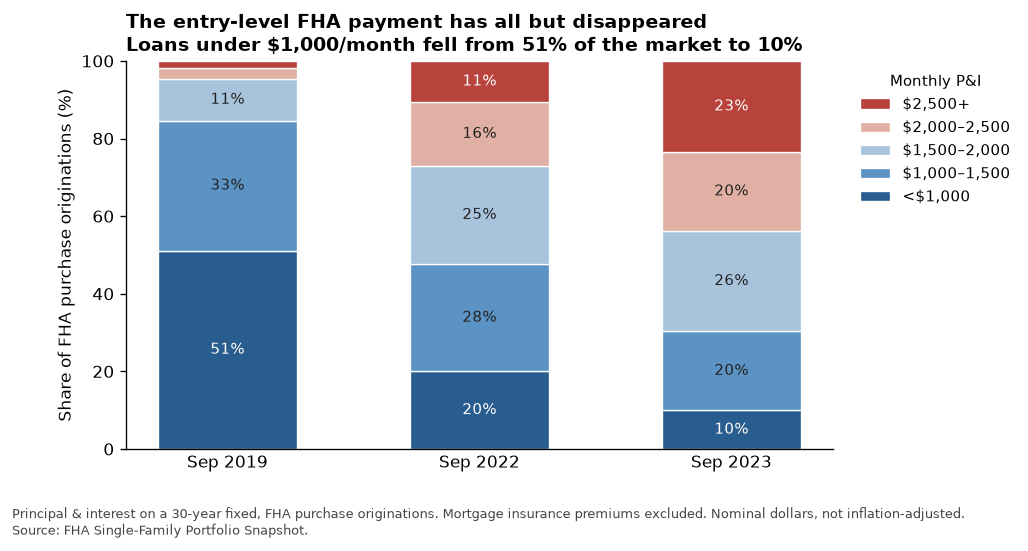

In [17]:
share = (pd.crosstab(d.pi_band, d.year, normalize="columns") * 100)[[2019, 2022, 2023]]

fig, ax = plt.subplots(figsize=(7.6, 4.2))
colors = ["#2a5d8f", "#5b93c4", "#a8c4dc", "#e0b0a4", "#b8433c"]
bottom = np.zeros(3)
for lab, col in zip(labels, colors):
    vals = share.loc[lab].values
    ax.bar(["Sep 2019", "Sep 2022", "Sep 2023"], vals, bottom=bottom,
           color=col, width=0.55, label=lab, edgecolor="white", lw=0.8)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 4:
            ax.text(i, b + v/2, f"{v:.0f}%", ha="center", va="center",
                    fontsize=9, color="white" if col in ("#2a5d8f", "#b8433c") else "#222")
    bottom += vals

ax.set_ylabel("Share of FHA purchase originations (%)")
ax.set_ylim(0, 100)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", length=0)
h, l = ax.get_legend_handles_labels()
ax.legend(h[::-1], l[::-1], bbox_to_anchor=(1.02, 1), loc="upper left",
          frameon=False, title="Monthly P&I", fontsize=9, title_fontsize=9)
ax.set_title("The entry-level FHA payment has all but disappeared\n"
             "Loans under $1,000/month fell from 51% of the market to 10%",
             fontsize=11.5, fontweight="bold", loc="left")
fig.text(0.0, -0.06,
    "Principal & interest on a 30-year fixed, FHA purchase originations. Mortgage insurance premiums excluded. "
    "Nominal dollars, not inflation-adjusted.\nSource: FHA Single-Family Portfolio Snapshot.",
    fontsize=7.6, ha="left", color="#444")

plt.savefig(f"{FIGS}/fig2_payment_tier_collapse.png", dpi=300, bbox_inches="tight")
plt.show()

### 5. What I scoped out, and why

A time-constrained assessment rewards knowing what not to chase. I checked three secondary threads
cheaply and dropped all three. The code below is the check that justified dropping them.

In [18]:
# thread 1: did the lender market consolidate as volume fell?
for y_ in [2019, 2022, 2023]:
    s = d.loc[d.year == y_, "originator"].value_counts(normalize=True)
    print(f"{y_}: lenders={len(s):>5} | top-10 share={s.head(10).sum()*100:5.1f}% | HHI={(s**2).sum()*1e4:6.0f}")

# thread 2: did the spread between cheap and expensive rates widen?
disp = d.groupby("year").rate.quantile([.10, .50, .90]).unstack()
disp["p90_p10_spread"] = disp[0.90] - disp[0.10]
display(disp.round(3))

# thread 3: did borrowers change how they fund the down payment?
display((pd.crosstab(d.DownPaymentSource, d.year, normalize="columns") * 100).round(2))

2019: lenders= 1180 | top-10 share= 24.0% | HHI=    95
2022: lenders= 1059 | top-10 share= 31.1% | HHI=   149
2023: lenders= 1030 | top-10 share= 31.5% | HHI=   175


,0.1,0.5,0.9,p90_p10_spread
year,,,,
2019,3.375,3.875,4.750,1.375
2022,4.750,5.625,6.250,1.500
2023,5.750,6.750,7.625,1.875


year,2019,2022,2023
DownPaymentSource,,,
Borrower,70.46,70.40,72.66
Employer,0.54,0.88,0.83
Gov Asst,1.44,0.50,1.03
Non Profit,0.24,0.17,0.23
Relative,27.31,28.05,25.25


- **Lender concentration.** Top-10 share rose from 24% to 32%, which sounds like consolidation but
  HHI is still ~175, far below the 1,500 threshold for even moderate concentration. The market has
  1,030 active originators. There is no antitrust story here.
- **Rate dispersion.** The P90–P10 spread widened from 1.38 to 1.88 pp, which could mean borrowers
  are being priced differently for the same risk. Without FICO or LTV I cannot separate that from
  legitimate risk-based pricing, and asserting it would be irresponsible.
- **Down payment source.** Moved less than 2 points across all categories. Nothing happened.

Each of these could carry a memo with better data. None of them can with this file.

### 6. Conclusion

1. The payment on the median FHA purchase loan rose 89% while loan size rose 41%. Rates, not prices,
   drove the change.
2. The sub-$1,000 monthly payment, half the FHA market in 2019 is now 10% of it.
3. Payment shock was uniform across regions (+85% to +97%). Volume outcomes were not (−14% to −46%).
4. Region explains 43% of cross-metro variation; payment growth explains 1.6% and adds nothing once
   region is known.

**Implication for federal policy.** MIP reductions, higher loan limits, and expanded down payment
assistance all raise borrower purchasing power against a shock that hit every market equally. They
cannot distinguish a market that stopped producing entry-level homes from one that did not. Where
supply is unresponsive, added purchasing power is more likely to be bid into prices than converted
into new owners.

### Limitations

1. FHA loans only: I cannot separate a decline in FHA's market share from a contraction of the
   whole market. This is the most important caveat.
2. No borrower income, credit score, or LTV, so composition shifts cannot be ruled out.
3. Nominal dollars, not inflation-adjusted.
4. One month per year: seasonally consistent, not cycle-adjusted.